In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(r"C:\Users\anike\OneDrive\Desktop\Dokumen\stock_data.csv")
df.head()

,Date,Company,Open,High,Low,Close,Volume,Daily Return
0,2020-01-01,Reliance,1550.691377,1556.870116,1545.638801,1555.474910,1278167,0.003085
1,2020-01-02,Reliance,1550.648722,1554.276670,1550.058749,1553.111194,4344769,0.001588
2,2020-01-03,Reliance,1548.477017,1549.686829,1531.924670,1541.491071,2307371,-0.004511
3,2020-01-04,Reliance,1541.713289,1544.372376,1534.709018,1535.296396,1527035,-0.004162
4,2020-01-05,Reliance,1528.262958,1531.410332,1493.180045,1496.168648,3416182,-0.021001


In [3]:
df.shape

(1040, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          1040 non-null   object 
 1   Company       1040 non-null   object 
 2   Open          1040 non-null   float64
 3   High          1040 non-null   float64
 4   Low           1040 non-null   float64
 5   Close         1040 non-null   float64
 6   Volume        1040 non-null   int64  
 7   Daily Return  1040 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 65.1+ KB


In [5]:
df.describe()

,Open,High,Low,Close,Volume,Daily Return
count,1040.000000,1040.000000,1040.000000,1040.000000,1.040000e+03,1040.000000
mean,1899.443460,1909.574743,1890.195733,1900.179766,2.923653e+06,0.000384
std,375.804947,375.842428,376.142830,376.239655,1.135217e+06,0.008057
min,1362.351817,1370.633360,1355.506295,1359.093409,1.002352e+06,-0.030151
25%,1628.795907,1636.154267,1616.560747,1625.193866,1.942797e+06,-0.004931
50%,1769.557682,1778.360519,1762.071948,1772.116681,2.849114e+06,0.000163
75%,2074.722673,2081.291402,2064.122649,2077.237413,3.876794e+06,0.005467
max,2642.579219,2650.267143,2632.963566,2636.859156,4.999453e+06,0.039841


In [6]:
df['Date'] = pd.to_datetime(df['Date'])


In [7]:
df = df.sort_values(['Company','Date'])

In [8]:
df.isnull().sum()

Date            0
Company         0
Open            0
High            0
Low             0
Close           0
Volume          0
Daily Return    0
dtype: int64

In [9]:
df.isnull().sum()

Date            0
Company         0
Open            0
High            0
Low             0
Close           0
Volume          0
Daily Return    0
dtype: int64

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df['Daily Return'] = (df['Close'] - df['Open']) / df['Open']

In [19]:
df['MA_50'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(50).mean())

In [20]:
df['Volatility'] = df.groupby('Company')['Daily Return'].transform(lambda x: x.rolling(30).std())

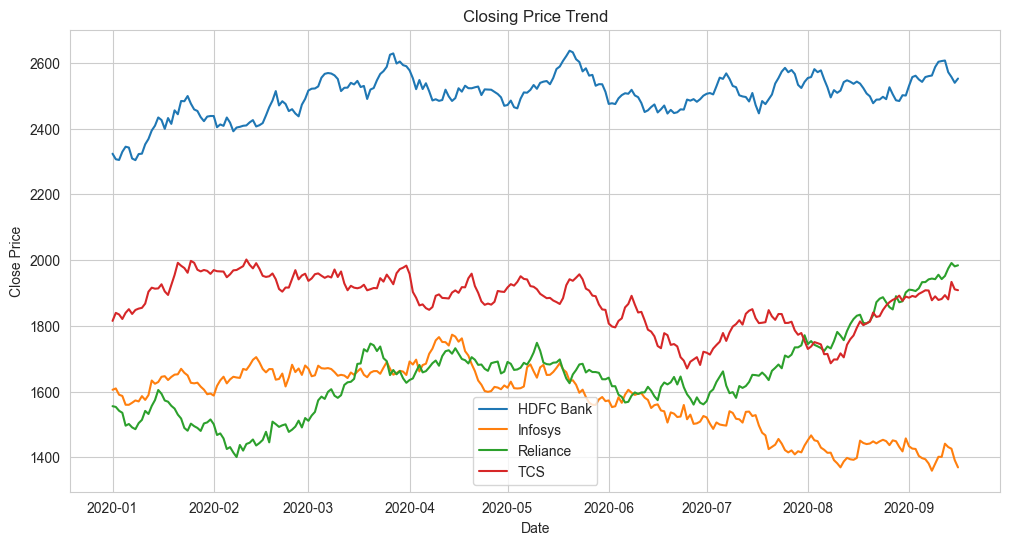

In [21]:
plt.figure(figsize=(12,6))

for company in df['Company'].unique():
    subset = df[df['Company'] == company]
    plt.plot(subset['Date'], subset['Close'], label=company)

plt.legend()
plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

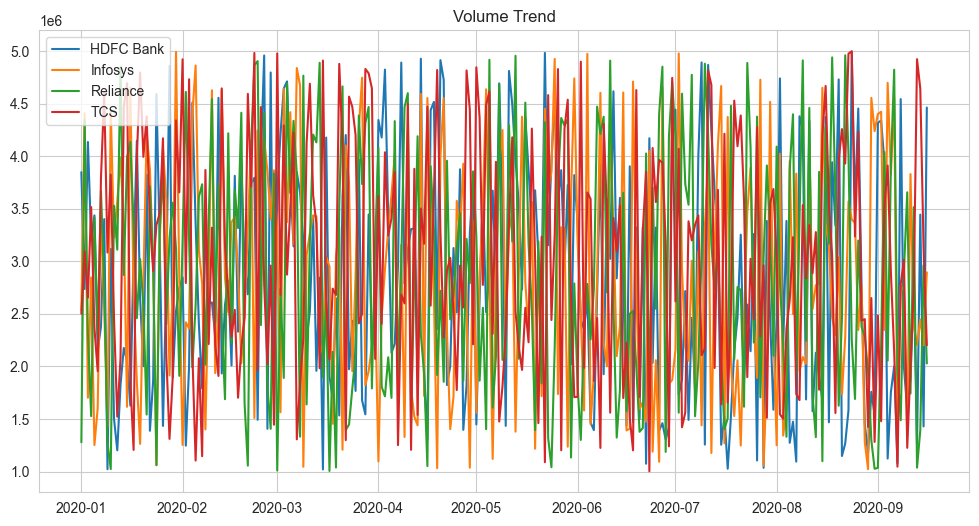

In [22]:
plt.figure(figsize=(12,6))

for company in df['Company'].unique():
    subset = df[df['Company'] == company]
    plt.plot(subset['Date'], subset['Volume'], label=company)

plt.legend()
plt.title("Volume Trend")
plt.show()

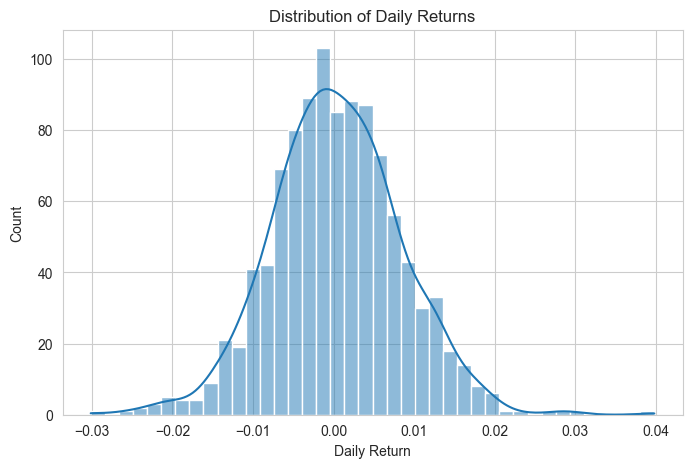

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['Daily Return'], bins=40, kde=True)
plt.title("Distribution of Daily Returns")
plt.show()

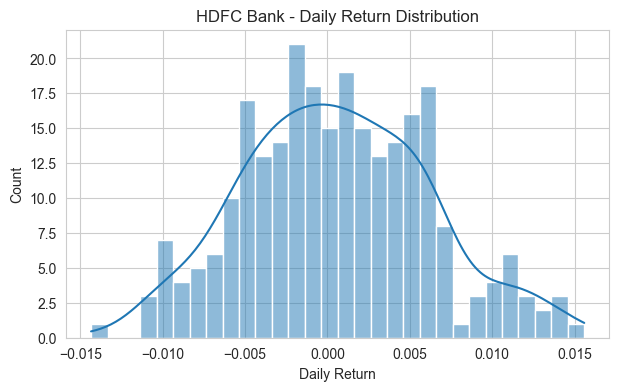

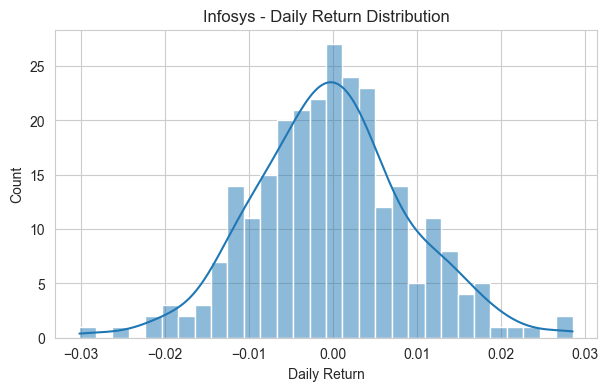

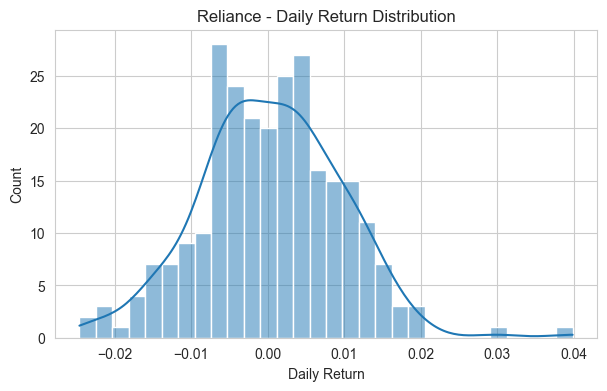

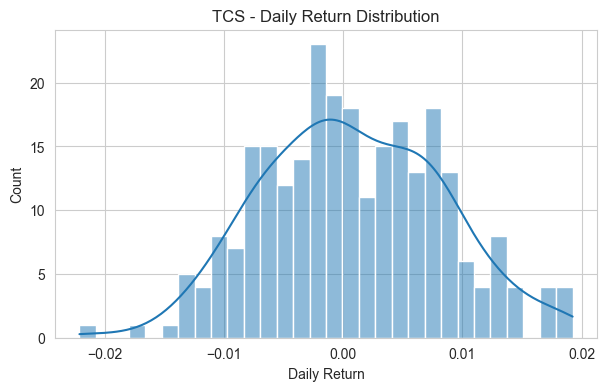

In [24]:
for company in df['Company'].unique():
    plt.figure(figsize=(7,4))
    sns.histplot(df[df['Company']==company]['Daily Return'], bins=30, kde=True)
    plt.title(f"{company} - Daily Return Distribution")
    plt.show()

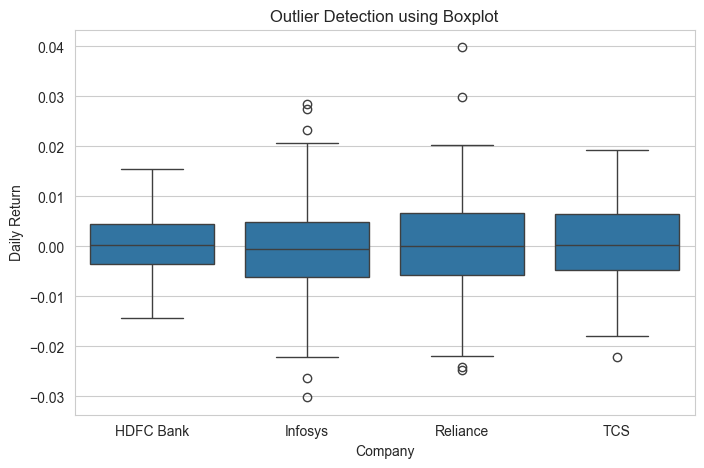

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Company', y='Daily Return', data=df)
plt.title("Outlier Detection using Boxplot")
plt.show()

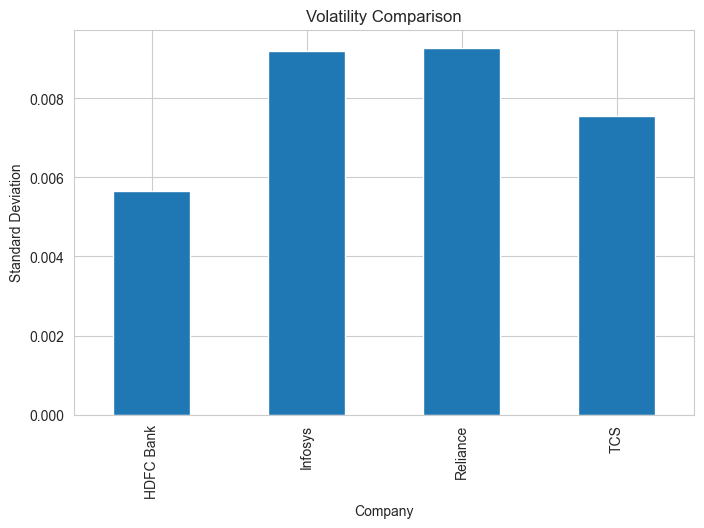

In [27]:
volatility = df.groupby('Company')['Daily Return'].std()

volatility.plot(kind='bar', figsize=(8,5))
plt.title("Volatility Comparison")
plt.ylabel("Standard Deviation")
plt.show()

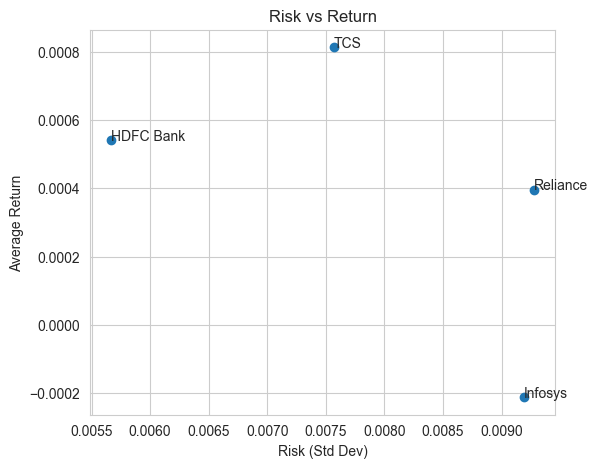

In [28]:
returns = df.groupby('Company')['Daily Return'].mean()
risk = df.groupby('Company')['Daily Return'].std()

plt.figure(figsize=(6,5))
plt.scatter(risk, returns)

for company in returns.index:
    plt.annotate(company, (risk[company], returns[company]))

plt.xlabel("Risk (Std Dev)")
plt.ylabel("Average Return")
plt.title("Risk vs Return")
plt.show()

In [29]:
risk_free_rate = 0.05 / 252   # approx daily risk free rate

sharpe_ratio = (returns - risk_free_rate) / risk

sharpe_ratio

Company
HDFC Bank    0.060373
Infosys     -0.044760
Reliance     0.021291
TCS          0.081398
Name: Daily Return, dtype: float64

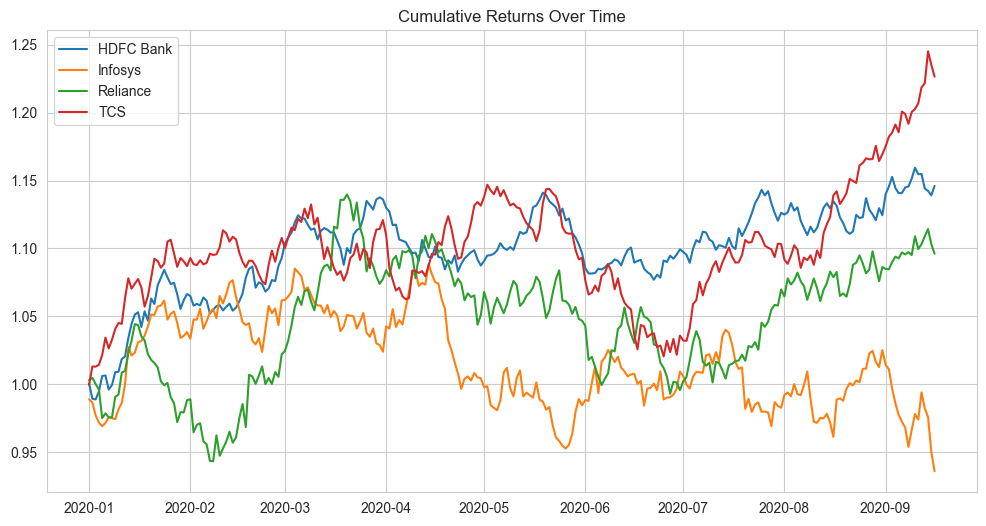

In [30]:
df['Cumulative Return'] = (1 + df['Daily Return']).groupby(df['Company']).cumprod()

plt.figure(figsize=(12,6))

for company in df['Company'].unique():
    subset = df[df['Company']==company]
    plt.plot(subset['Date'], subset['Cumulative Return'], label=company)

plt.legend()
plt.title("Cumulative Returns Over Time")
plt.show()

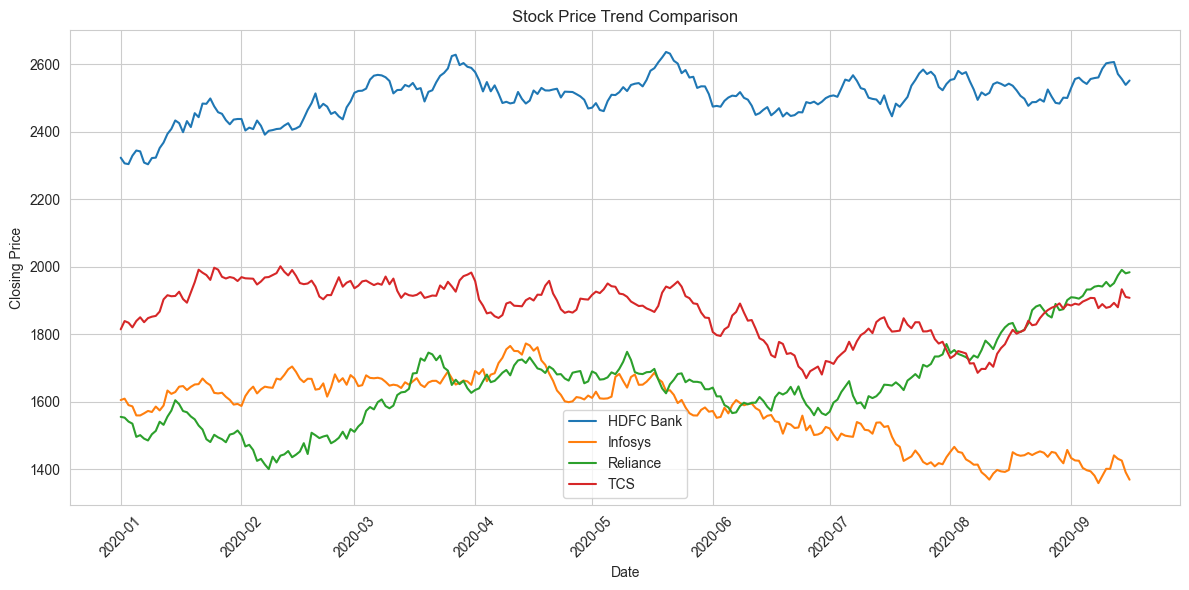

In [33]:
# 📌 Stock Price Trend Comparison

plt.figure(figsize=(12,6))

for company in df['Company'].unique():
    company_data = df[df['Company'] == company]
    plt.plot(company_data['Date'], company_data['Close'], label=company)

plt.title("Stock Price Trend Comparison")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

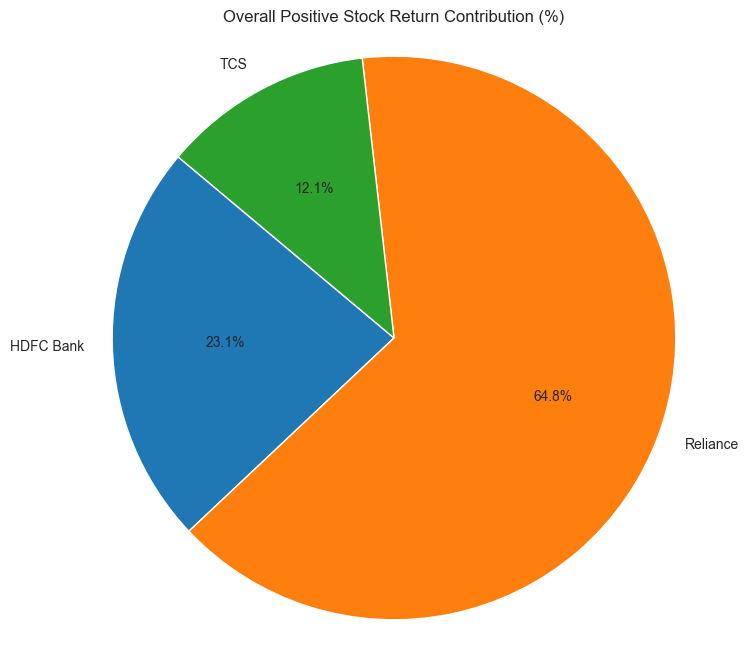

In [34]:
# 📌 Sort data by Date first (VERY IMPORTANT)

df = df.sort_values(['Company', 'Date'])

# 📌 Calculate Total Return %

total_return = df.groupby('Company')['Close'].apply(
    lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100
)

# 📌 Remove negative values (pie chart issue fix)
total_return = total_return[total_return > 0]

plt.figure(figsize=(8,8))
plt.pie(total_return.values,
        labels=total_return.index,
        autopct='%1.1f%%',
        startangle=140)

plt.title("Overall Positive Stock Return Contribution (%)")
plt.axis('equal')
plt.show()

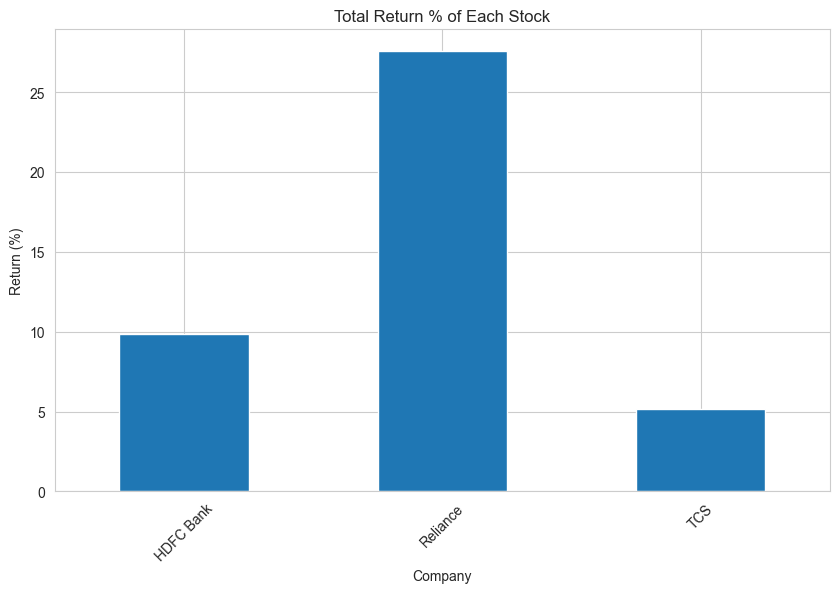

In [35]:
plt.figure(figsize=(10,6))
total_return.plot(kind='bar')
plt.title("Total Return % of Each Stock")
plt.ylabel("Return (%)")
plt.xticks(rotation=45)
plt.show()

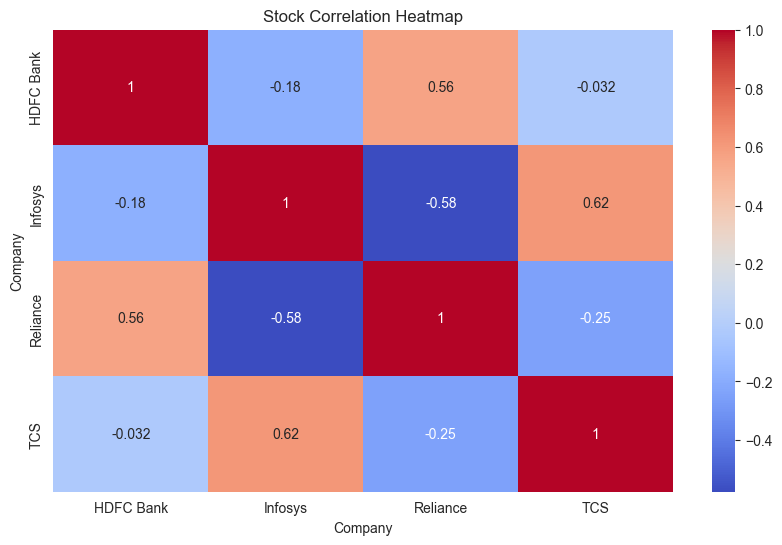

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_close = df.pivot(index='Date', columns='Company', values='Close')

plt.figure(figsize=(10,6))
sns.heatmap(pivot_close.corr(), annot=True, cmap='coolwarm')
plt.title("Stock Correlation Heatmap")
plt.show()

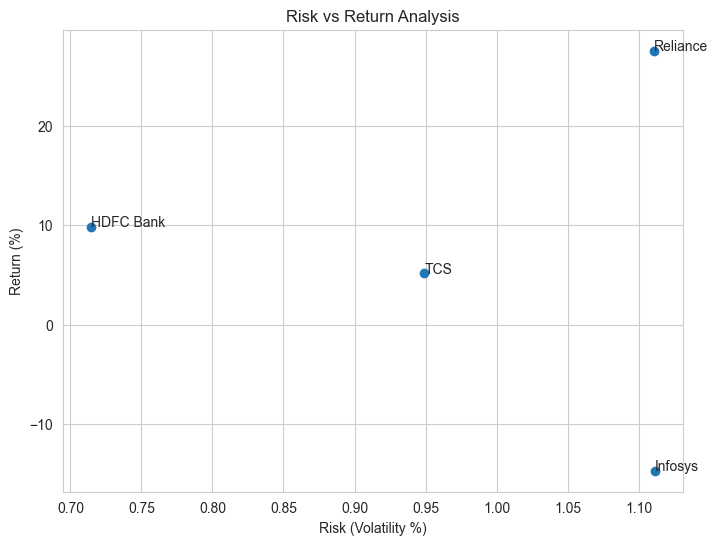

In [37]:
returns = df.groupby('Company')['Close'].pct_change()

risk_return = df.groupby('Company')['Close'].agg(
    Return=lambda x: (x.iloc[-1]/x.iloc[0]-1)*100,
    Risk=lambda x: x.pct_change().std()*100
)

plt.figure(figsize=(8,6))
plt.scatter(risk_return['Risk'], risk_return['Return'])

for i in risk_return.index:
    plt.text(risk_return['Risk'][i], risk_return['Return'][i], i)

plt.xlabel("Risk (Volatility %)")
plt.ylabel("Return (%)")
plt.title("Risk vs Return Analysis")
plt.show()

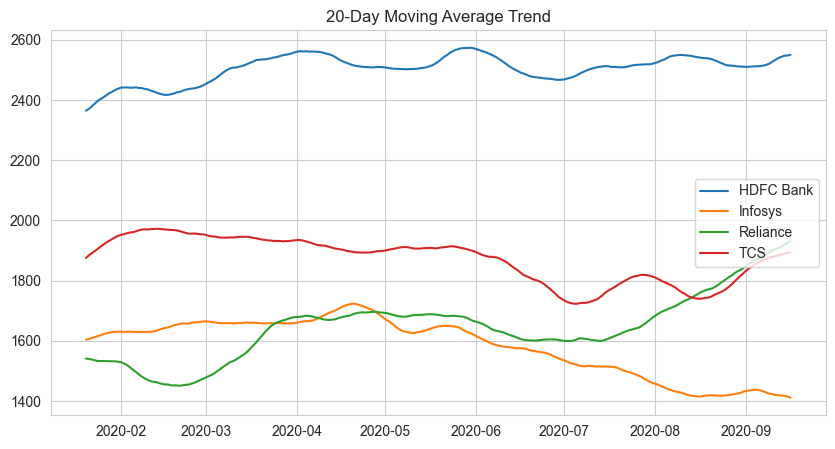

In [38]:
df['MA20'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(20).mean())

plt.figure(figsize=(10,5))
for company in df['Company'].unique():
    temp = df[df['Company'] == company]
    plt.plot(temp['Date'], temp['MA20'], label=company)

plt.legend()
plt.title("20-Day Moving Average Trend")
plt.show()